Opgave 1.1
We have finished out two methods and will start by testing them
a. utility(). We test if the utility is positive, if it is a number and if more of one of the items gives more u (we know this because of $w\in[0,1]$)

In [1]:
#importing the class from Consumer.py
from Consumer import ConsumerClass
import numpy as np

#setting up the model
model = ConsumerClass()
u = model.utility(1,1,1)
#test if the utility value can be printed
print(f'utility value is {u}')
#test: is it a number
assert np.isfinite(u)
print('Is finite: True')
#test: is it positve

assert u>0
print('u is positive: True')

#test: is it true that w is between 0 and 1
u1 = model.utility(1,1,2)
u2 = model.utility(1,2,2)
assert u2 > u1
print('Is u2>u1: True')
print('All tests passed')

utility value is 1.0
Is finite: True
u is positive: True
Is u2>u1: True
All tests passed


Test of value_of_choice()

In [2]:
model2 = ConsumerClass()
u = model2.value_of_choice(0.5,0.5)
print(u)

#testing if it is a number
assert np.isfinite(u)
print('Is finite: True')

#test if the manuel calculation gives the same result at the method
x1,x2,x3 = model2.quantities(0.5,0.5)
u_manuel=model2.utility(x1,x2,x3)
assert np.isclose(u,u_manuel)
print('value_of_choice() = manuel calculation test: True')

#test if the share are alle between 0 and 1 and they all sum to 1
test_values = [
    (0.1, 0.3),
    (0.5, 0.5),
    (0.9, 0.2),
    (0.0, 0.0),
    (1.0, 1.0),
    (0.0, 1.0),
    (1.0, 0.0)
]

for s1, w in test_values:

    shares = model.shares(s1, w)

    assert np.isclose(sum(shares), 1.0)
    assert all(0 <= s <= 1 for s in shares)
print('Share tests passed')
print("All tests passed")

3.3630852682729575
Is finite: True
value_of_choice() = manuel calculation test: True
Share tests passed
All tests passed


1.2 Calibrations. Now we will change the value of $\sigma$ and calculate the utlity again. We can so it in only one line

In [3]:
#we change the value of the substitution of bus and train.
model = ConsumerClass(par={'sigma_B':3.0})
#test if all shares sum to 1 and are between 0 and one. 
test_values = [
    (0.1, 0.3),
    (0.5, 0.5),
    (0.9, 0.2),
    (0.0, 0.0),
    (1.0, 1.0),
    (0.0, 1.0),
    (1.0, 0.0)
]

for s1, w in test_values:

    shares = model.shares(s1, w)

    assert np.isclose(sum(shares), 1.0)
    assert all(0 <= s <= 1 for s in shares)

print("all shares tests passed")


all shares tests passed


3. Relative prices and demand
1. We solve the model with $p_3=0.5$ and $p_3=3$ and plot the tree budgt shares and quantities for both calibrations in the same figure

In [4]:
# Calibration 1
p3_values = np.linspace(0.5, 3, 26)
results_cal1 = []

for p3 in p3_values:
    model = ConsumerClass(par={'sigma_B': 0.4, 'p3': p3})

    result = minimize(
        model.objective,
        x0=[0.5, 0.5],
        bounds=[(0, 1), (0, 1)]
    )

    s1_opt = result.x[0]
    w_opt = result.x[1]

    s1, s2, s3 = model.shares(s1_opt, w_opt)
    x1, x2, x3 = model.quantities(s1_opt, w_opt)

    results_cal1.append({
        'p3': p3,
        's1': s1,
        's2': s2,
        's3': s3,
        'x1': x1,
        'x2': x2,
        'x3': x3
    })


# Calibration 2
p3_values = np.linspace(0.5, 3, 26)
results_cal2 = []

for p3 in p3_values:
    model = ConsumerClass(par={'sigma_B': 3.0, 'p3': p3})

    result = minimize(
        model.objective,
        x0=[0.5, 0.5],
        bounds=[(0, 1), (0, 1)]
    )

    s1_opt = result.x[0]
    w_opt = result.x[1]

    s1, s2, s3 = model.shares(s1_opt, w_opt)
    x1, x2, x3 = model.quantities(s1_opt, w_opt)

    results_cal2.append({
        'p3': p3,
        's1': s1,
        's2': s2,
        's3': s3,
        'x1': x1,
        'x2': x2,
        'x3': x3
    })
plt.figure()

p3_1 = [r['p3'] for r in results_cal1]
p3_2 = [r['p3'] for r in results_cal2]

plt.plot(p3_1, [r['s1'] for r in results_cal1], label='Food - calibration 1')
plt.plot(p3_1, [r['s2'] for r in results_cal1], label='Bus - calibration 1')
plt.plot(p3_1, [r['s3'] for r in results_cal1], label='Train - calibration 1')

plt.plot(p3_2, [r['s1'] for r in results_cal2], '--', label='Food - calibration 2')
plt.plot(p3_2, [r['s2'] for r in results_cal2], '--', label='Bus - calibration 2')
plt.plot(p3_2, [r['s3'] for r in results_cal2], '--', label='Train - calibration 2')

plt.xlabel('p3')
plt.ylabel('Budget share')
plt.title('Budget shares')
plt.legend()
plt.grid()
plt.show()

NameError: name 'minimize' is not defined

The figure shows that food changes very little between the calibrations, which makes sense since the substitution of food vs travel and income is not affected by the calibrations. At $p_3=1$ we get the same budget share for the bus and train in both calibrations, this is because of the way in which we nested the two travel goods. At $p_3=1$ the two items cost the same and are prefered with the same wheight. Even though the substitution changes there is at $p_3=1$ no price difference to respond to and the consumer will buy the same about of each good.

3.2 In the first calibration the budget share is incresed at higher $p_3$ and in the second it is lowered at higher $p_3$.

3.3 When the price of train tickets get more expensive in calibration 1 we get a lower budget share of bus tickets and a higher budget share of train ticekts. incalibration 2 we see that the budget share of bus ticets acually increases and train ticets deacrese. The reason for this is that in the first calibration we have $\sigma<1$. This means that bus and train ticekts are complements, so the consumer will want consume both and doues not like to substitute bus ticekts for train tickets.

In calibration 2 the degree of substitution havs changed and now the two goods are substitues since $\sigma>1$. The consumer will now substitute bus tickets for train tickets when the price of train ticekts goes up. This results in a rise in the budget share of bus tickes.

3.4 The effect on food is very limited but it will lead to a fall in the budget share of food for both calibrations. In the first calibraton the lower degree of substitution means, that the consumer will not switch over to bus tickets as much as in calibration 2 and therefore spend more money on travel. This means that there is less money left over to buy food with. In the second calibration the same thing happens essentially, but since the degree of substituion has changed, the consumer will now switch over to buying bus tickets. since the price of bus tickets has not increased the consumer has more money left over that in the first calibration to buy food with.

5.0
I this part of the assignment we will see what happens when we assing $CO_2$ values to the two transport methods. This will allow us to see how the changes in price of one of the transport goods changes the total CO2 emitted and what the optimal price of the transport good is if the goal is to minimize CO2. This is especially intresting since the goverment in Denmark, and to a larger extent in a lot of other contries, have a lot to say in the price setting of bus and train tickets. This could be used to minimize the pollution cost of transprort. for the polution cost of transportation we have used data from Concito. The bus and train ticket is the co2 cost of a 50 km trip, for the food category it is the co2 polution of buying 1 kg og potatos

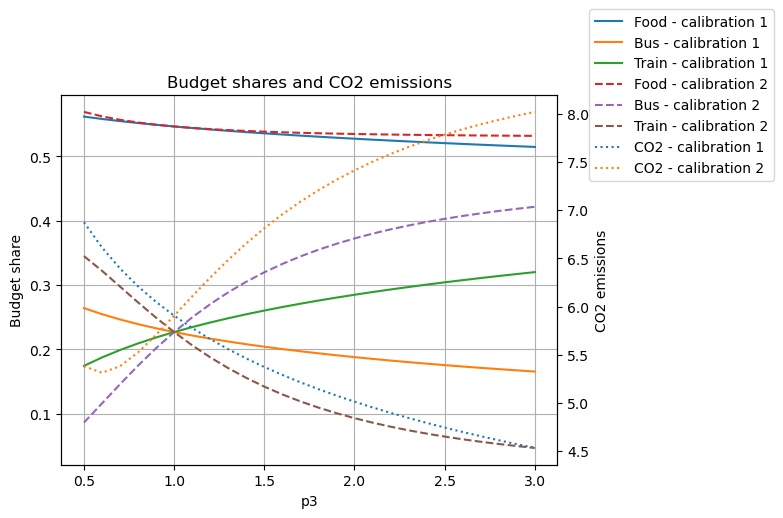

In [ ]:
#calibration 2

results_cal1 = []

for p3 in p3_values:
    model = ConsumerClass(par={'sigma_B': 0.4, 'p3': p3})

    result = minimize(
        model.objective,
        x0=[0.5, 0.5],
        bounds=[(0, 1), (0, 1)]
    )

    s1_opt = result.x[0]
    w_opt = result.x[1]

    s1, s2, s3 = model.shares(s1_opt, w_opt)
    x1, x2, x3 = model.quantities(s1_opt, w_opt)

    co2_food = 0.350
    co2_bus = 1.450
    co2_train = 0.310

    co2 = co2_food*x1 + co2_bus*x2 + co2_train*x3

    results_cal1.append({
        'p3': p3,
        's1': s1,
        's2': s2,
        's3': s3,
        'x1': x1,
        'x2': x2,
        'x3': x3,
        'co2': co2
    })

# Calibration 2
p3_values = np.linspace(0.5, 3, 26)
results_cal2 = []

for p3 in p3_values:
    model = ConsumerClass(par={'sigma_B': 3.0, 'p3': p3})

    result = minimize(
        model.objective,
        x0=[0.5, 0.5],
        bounds=[(0, 1), (0, 1)]
    )

    s1_opt = result.x[0]
    w_opt = result.x[1]

    s1, s2, s3 = model.shares(s1_opt, w_opt)
    x1, x2, x3 = model.quantities(s1_opt, w_opt)
    co2_food = 0.350
    co2_bus = 1.450
    co2_train = 0.310

    co2 = co2_food*x1 + co2_bus*x2 + co2_train*x3

    results_cal2.append({
        'p3': p3,
        's1': s1,
        's2': s2,
        's3': s3,
        'x1': x1,
        'x2': x2,
        'x3': x3,
        'co2': co2
    })
fig, ax1 = plt.subplots()

#Budget shares venstre side

ax1.plot(
    p3_1,
    [r['s1'] for r in results_cal1],
    label='Food - calibration 1'
)

ax1.plot(
    p3_1,
    [r['s2'] for r in results_cal1],
    label='Bus - calibration 1'
)

ax1.plot(
    p3_1,
    [r['s3'] for r in results_cal1],
    label='Train - calibration 1'
)

ax1.plot(
    p3_2,
    [r['s1'] for r in results_cal2],
    '--',
    label='Food - calibration 2'
)

ax1.plot(
    p3_2,
    [r['s2'] for r in results_cal2],
    '--',
    label='Bus - calibration 2'
)

ax1.plot(
    p3_2,
    [r['s3'] for r in results_cal2],
    '--',
    label='Train - calibration 2'
)

ax1.set_xlabel('p3')
ax1.set_ylabel('Budget share')
ax1.grid()

#CO2 right axis

ax2 = ax1.twinx()

ax2.plot(
    p3_1,
    [r['co2'] for r in results_cal1],
    ':',
    label='CO2 - calibration 1'
)

ax2.plot(
    p3_2,
    [r['co2'] for r in results_cal2],
    ':',
    label='CO2 - calibration 2'
)

ax2.set_ylabel('CO2 emissions')
#legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center left',
    bbox_to_anchor=(1.05, 1.00)
)

plt.title('Budget shares and CO2 emissions')
plt.show()


Now the figure includes the $CO_2$ cost in each calibration. An intresting result is that in calibration 2 we see that the $CO_2$ goes from deacresing to increasing, while the $CO_2$ cost curve for calibration 1 is decreasing. We will now calculate the values of $p3$ that minimizes the $CO_2$ emission.

In [ ]:
min_cal1 = min(results_cal1, key=lambda x: x['co2'])
min_cal2 = min(results_cal2, key=lambda x: x['co2'])

print("Kalibration 1:")
print(f"Minimum CO2 = {min_cal1['co2']:.4f}")
print(f"p3 = {min_cal1['p3']:.2f}")

print("\nKalibration 2:")
print(f"Minimum CO2 = {min_cal2['co2']:.4f}")
print(f"p3 = {min_cal2['p3']:.2f}")

Kalibration 1:
Minimum CO2 = 4.5314
p3 = 3.00

Kalibration 2:
Minimum CO2 = 5.3121
p3 = 0.60
